In [5]:

import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

---
# ***1. Loading Date***

In [7]:
df = pd.read_csv("C:/Users/adika/Downloads/train.csv")

In [8]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
# ***2. EDA (Exploratory Data Analysis)***

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## ***2.1 Understanding Data***

In [10]:
df.shape

(1460, 81)

In [11]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## ***2.2 Handling Missing Values***

In [12]:
cols = df.columns

In [13]:
i=0
for col in cols:
    if(df[col].isnull().sum() !=0):
        print(i ,col,"-> " ,df[col].isnull().sum())
        print(df[col])
        i=i+1

0 LotFrontage ->  259
0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64
1 Alley ->  1369
0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1455    NaN
1456    NaN
1457    NaN
1458    NaN
1459    NaN
Name: Alley, Length: 1460, dtype: object
2 MasVnrType ->  872
0       BrkFace
1           NaN
2       BrkFace
3           NaN
4       BrkFace
         ...   
1455        NaN
1456      Stone
1457        NaN
1458        NaN
1459        NaN
Name: MasVnrType, Length: 1460, dtype: object
3 MasVnrArea ->  8
0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64
4 BsmtQual ->  37
0       Gd
1       Gd
2       Gd
3       TA
4       Gd
        ..
1455    Gd
1456    Gd
1457    TA
1458    TA
1459  

In [10]:
# Dropping columns which have Missing values > 850
cols_to_drop = ["Alley", "MiscFeature","Fence", "PoolQC", "MasVnrType"]
df = df.drop(columns=cols_to_drop)

In [11]:
mean_imp = SimpleImputer(strategy="mean")
mode_imp = SimpleImputer(strategy="most_frequent")
median_imp = SimpleImputer(strategy="median")

df[["LotFrontage"]] = mean_imp.fit_transform(df[["LotFrontage"]])
df[["LotFrontage"]] = mean_imp.fit_transform(df[["LotFrontage"]])

df[["GarageCond"]] = mode_imp.fit_transform(df[["GarageCond"]])
df[["GarageQual"]] = mode_imp.fit_transform(df[["GarageQual"]])
df[["GarageFinish"]] = mode_imp.fit_transform(df[["GarageFinish"]])
df[["GarageType"]] = mode_imp.fit_transform(df[["GarageType"]])
df[["FireplaceQu"]] = mode_imp.fit_transform(df[["FireplaceQu"]])
df[["FireplaceQu"]] = mode_imp.fit_transform(df[["FireplaceQu"]])
df[["Electrical"]] = mode_imp.fit_transform(df[["Electrical"]])
df[["BsmtFinType2"]] = mode_imp.fit_transform(df[["BsmtFinType2"]])
df[["BsmtFinType1"]] = mode_imp.fit_transform(df[["BsmtFinType1"]])
df[["BsmtExposure"]] = mode_imp.fit_transform(df[["BsmtExposure"]])
df[["BsmtCond"]] = mode_imp.fit_transform(df[["BsmtCond"]])
df[["BsmtQual"]] = mode_imp.fit_transform(df[["BsmtQual"]])

df[["GarageYrBlt"]] = median_imp.fit_transform(df[["GarageYrBlt"]])
df[["MasVnrArea"]] = median_imp.fit_transform(df[["MasVnrArea"]])
df[["MasVnrArea"]] = median_imp.fit_transform(df[["MasVnrArea"]])

cleaned_df = df

In [12]:
cleaned_df.isnull().sum().sum()

np.int64(0)

In [13]:
cleaned_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


## ***2.3 Handling Duplicate Values***

In [14]:
cleaned_df.duplicated().sum()

np.int64(0)

> No Duplicate values

## ***2.4 Data Visulaization***

In [15]:
cleaned_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenP

### ***2.4.1 Feature Distribution***

In [16]:
sns.set_style("dark")

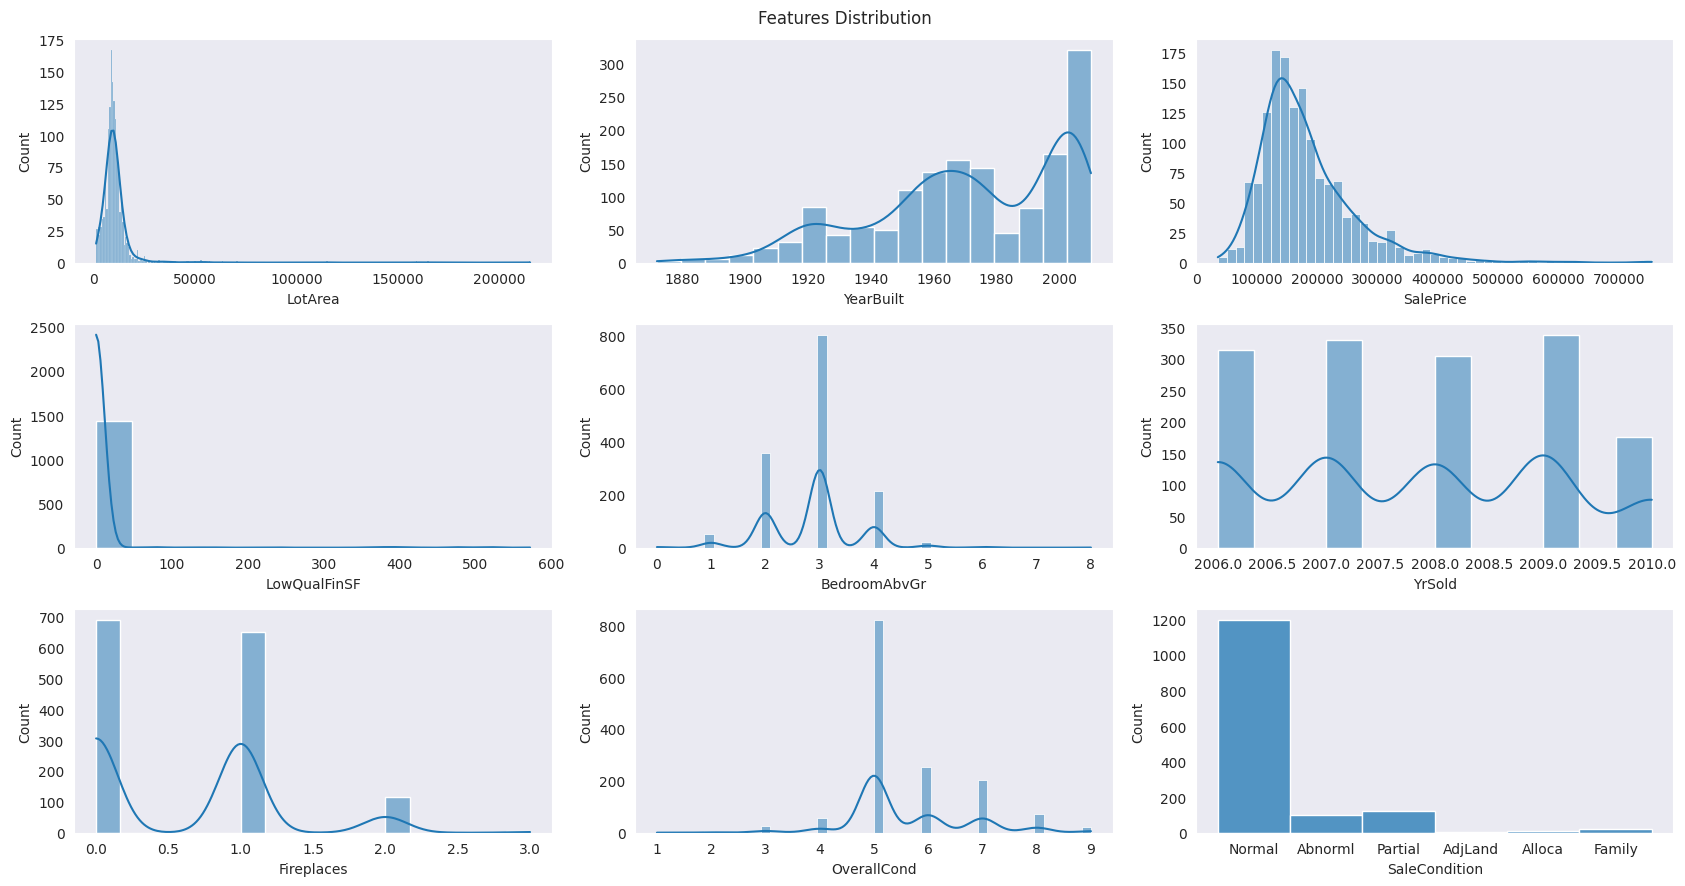

In [17]:
fig, axes = plt.subplots(3,3, figsize=(17,9))
sns.histplot(ax=axes[0,0], data=cleaned_df, x="LotArea",kde=True)
sns.histplot(ax=axes[0,1], data=cleaned_df, x="YearBuilt",kde=True)
sns.histplot(ax=axes[0,2], data=cleaned_df, x="SalePrice",kde=True)
sns.histplot(ax=axes[1,0], data=cleaned_df, x="LowQualFinSF",kde=True)
sns.histplot(ax=axes[1,1], data=cleaned_df, x="BedroomAbvGr",kde=True)
sns.histplot(ax=axes[1,2], data=cleaned_df, x="YrSold",kde=True)
sns.histplot(ax=axes[2,0], data=cleaned_df, x="Fireplaces",kde=True)
sns.histplot(ax=axes[2,1], data=cleaned_df, x="OverallCond",kde=True)
sns.histplot(ax=axes[2,2], data=cleaned_df, x="SaleCondition")
fig.suptitle("Features Distribution")
plt.tight_layout()

plt.show()


### ***2.4.2 Correlation Heatmap***

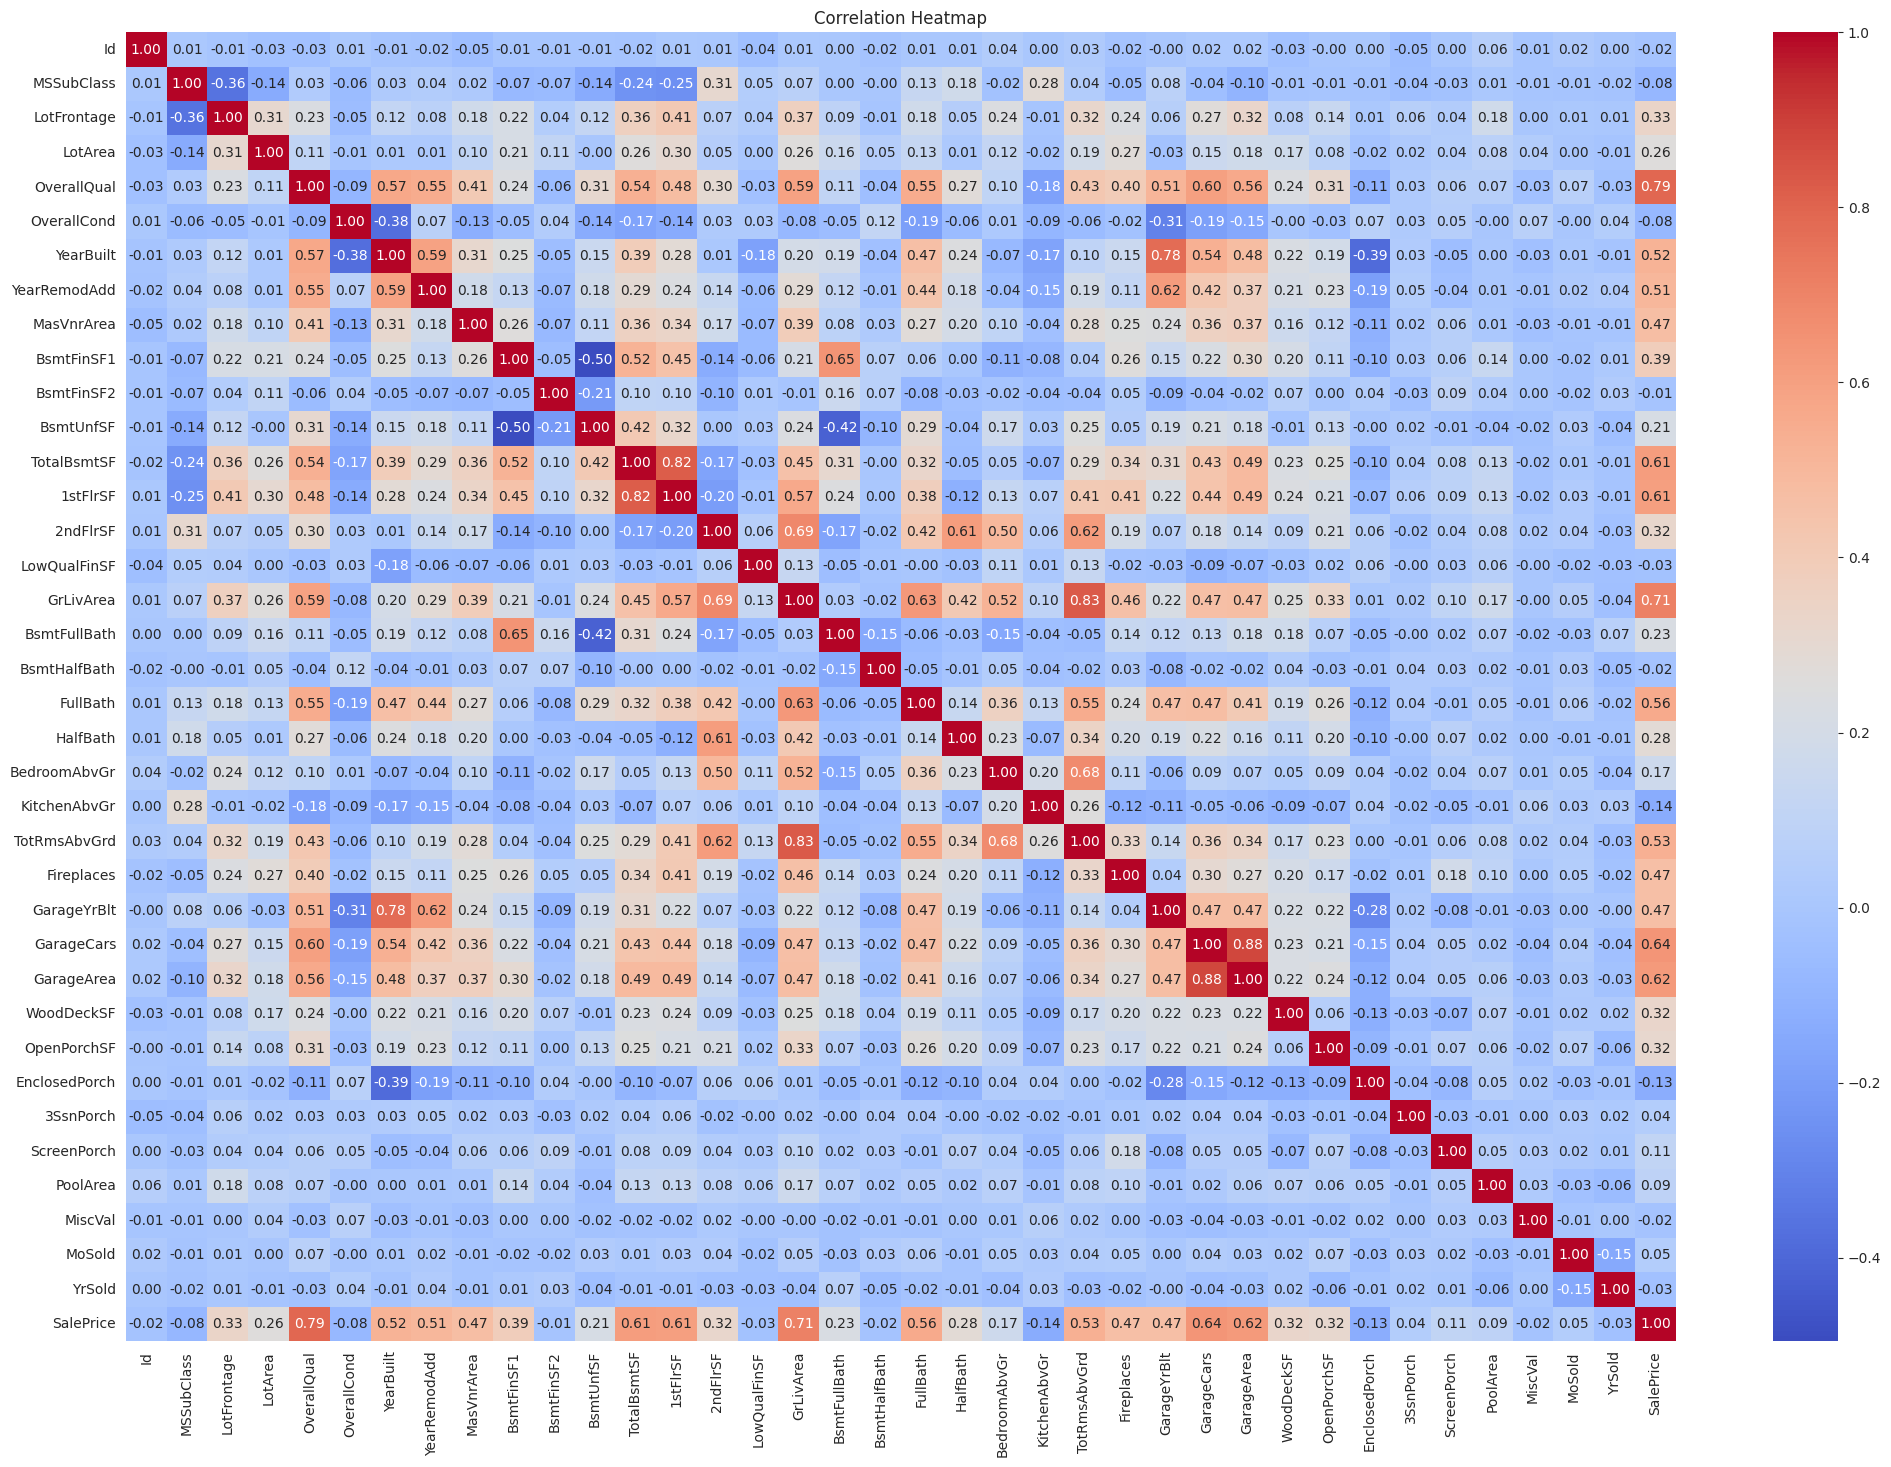

In [18]:
numer_cols = cleaned_df.select_dtypes(include="number").columns
corr_matrix = cleaned_df[numer_cols].corr()
plt.figure(figsize=(25,17))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

#### Highly Correlated Features
> `TotRmsAbvGrd: Total rooms above grade,  OverallQual: Overall material and finish quality, GarageYrBlt: Year garage was built, 1stFlrSF: First Floor square feet, GrLivArea: Above grade (ground) living area square feet ,BsmtUnfSF: Unfinished square feet of basement area.`


---
#  ***3. Feature Engineering***

In [19]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## ***3.1 Encoding Categorical Features***

In [20]:
categorical_cols =  cleaned_df.select_dtypes(include="object").columns
categorical_cols

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [21]:
# Checking how many avg categories are present in the categorical cols
length = len(categorical_cols)
summ = 0
for i in categorical_cols:
    print(f"For {i} -> {cleaned_df[i].nunique()} categories")
    summ += cleaned_df[i].nunique()

print("Average categories : ", summ/length)


For MSZoning -> 5 categories
For Street -> 2 categories
For LotShape -> 4 categories
For LandContour -> 4 categories
For Utilities -> 2 categories
For LotConfig -> 5 categories
For LandSlope -> 3 categories
For Neighborhood -> 25 categories
For Condition1 -> 9 categories
For Condition2 -> 8 categories
For BldgType -> 5 categories
For HouseStyle -> 8 categories
For RoofStyle -> 6 categories
For RoofMatl -> 8 categories
For Exterior1st -> 15 categories
For Exterior2nd -> 16 categories
For ExterQual -> 4 categories
For ExterCond -> 5 categories
For Foundation -> 6 categories
For BsmtQual -> 4 categories
For BsmtCond -> 4 categories
For BsmtExposure -> 4 categories
For BsmtFinType1 -> 6 categories
For BsmtFinType2 -> 6 categories
For Heating -> 6 categories
For HeatingQC -> 5 categories
For CentralAir -> 2 categories
For Electrical -> 5 categories
For KitchenQual -> 4 categories
For Functional -> 7 categories
For FireplaceQu -> 5 categories
For GarageType -> 6 categories
For GarageFinish -

In [22]:
cleaned_df["Condition2"]

0       Norm
1       Norm
2       Norm
3       Norm
4       Norm
        ... 
1455    Norm
1456    Norm
1457    Norm
1458    Norm
1459    Norm
Name: Condition2, Length: 1460, dtype: object

In [23]:
cleaned_df["Condition1"]

0        Norm
1       Feedr
2        Norm
3        Norm
4        Norm
        ...  
1455     Norm
1456     Norm
1457     Norm
1458     Norm
1459     Norm
Name: Condition1, Length: 1460, dtype: object

In [24]:
cleaned_df["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [25]:
cleaned_df["Exterior1st"].value_counts()

Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64

In [26]:
cleaned_df["Exterior2nd"].value_counts()

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

In [27]:
len(cleaned_df.columns)

76

> `Because we already have High dimensional data, So by using OneHotEncoder does not make sense that's why I am using LabelEncoder`

In [28]:
cols_to_drop = []
for i in categorical_cols:
    if cleaned_df[i].nunique() > 9:
        cols_to_drop.append(i)

print(cols_to_drop)

['Neighborhood', 'Exterior1st', 'Exterior2nd']


In [29]:
new_df = cleaned_df.drop(columns=cols_to_drop)
new_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'Screen

In [30]:
le = LabelEncoder()

new_cate_cols = new_df.select_dtypes(include="object").columns

for col in new_cate_cols:
    new_df[col] = le.fit_transform(new_df[col])

new_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,3,3,0,4,...,0,0,0,0,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,3,3,0,2,...,0,0,0,0,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,0,3,0,4,...,0,0,0,0,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,0,3,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,0,3,0,2,...,0,0,0,0,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,3,3,0,4,...,0,0,0,0,0,8,2007,8,4,175000
1456,1457,20,3,85.0,13175,1,3,3,0,4,...,0,0,0,0,0,2,2010,8,4,210000
1457,1458,70,3,66.0,9042,1,3,3,0,4,...,0,0,0,0,2500,5,2010,8,4,266500
1458,1459,20,3,68.0,9717,1,3,3,0,4,...,112,0,0,0,0,4,2010,8,4,142125


## ***3.2 Highlighting Important Features***

In [31]:
#TotRmsAbvGrd: Total rooms above grade,  OverallQual: Overall material and finish quality, GarageYrBlt: Year garage was built, 
#1stFlrSF: First Floor square feet, GrLivArea: Above grade (ground) living area square feet ,BsmtUnfSF: Unfinished square feet of basement area.

new_df["TotRmsAbvGrd"] = new_df["TotRmsAbvGrd"]**2
new_df["OverallQual"] = new_df["TotRmsAbvGrd"]**2
# new_df["GarageYrBlt"] = new_df["TotRmsAbvGrd"]**2 because it will become large value
new_df["1stFlrSF"] = new_df["TotRmsAbvGrd"]**2
new_df["GrLivArea"] = new_df["TotRmsAbvGrd"]**2
new_df["BsmtUnfSF"] = new_df["TotRmsAbvGrd"]**2

## ***3.3 Feature Selection***

In [32]:
new_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'Screen

In [33]:
# Id, MiscVal(too many zeros), 
new_df["MiscVal"].value_counts()

MiscVal
0        1408
400        11
500         8
700         5
450         4
600         4
2000        4
1200        2
480         2
350         1
15500       1
800         1
3500        1
1300        1
54          1
620         1
560         1
1400        1
8300        1
1150        1
2500        1
Name: count, dtype: int64

In [34]:
new_df = new_df.drop(columns=["Id", "MiscVal","ScreenPorch", "3SsnPorch"])
new_df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,PoolArea,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450,1,3,3,0,4,0,...,2,0,61,0,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,2,298,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,2,0,42,0,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,2,0,35,272,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,2,192,84,0,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917,1,3,3,0,4,0,...,2,0,40,0,0,8,2007,8,4,175000
1456,20,3,85.0,13175,1,3,3,0,4,0,...,2,349,0,0,0,2,2010,8,4,210000
1457,70,3,66.0,9042,1,3,3,0,4,0,...,2,0,60,0,0,5,2010,8,4,266500
1458,20,3,68.0,9717,1,3,3,0,4,0,...,2,366,0,112,0,4,2010,8,4,142125


In [35]:
X = new_df.drop(columns=["SalePrice"])
y = new_df["SalePrice"]

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [37]:
X_train.shape

(1168, 68)

In [38]:
y_test.shape

(292,)

## ***3.4 Scaling Features***

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
X_train_scaled

array([[-0.8667643 , -0.05479609, -0.01288179, ...,  1.65006527,
         0.31666197,  0.20177167],
       [ 0.07410996, -0.05479609, -0.5027726 , ...,  0.89367742,
         0.31666197,  0.20177167],
       [-0.63154574, -0.05479609, -0.14648837, ...,  0.13728958,
         0.31666197,  0.20177167],
       ...,
       [-0.8667643 , -0.05479609, -0.45823707, ..., -1.37548612,
         0.31666197,  0.20177167],
       [-0.16110861, -0.05479609, -0.68091471, ..., -0.61909827,
         0.31666197,  0.20177167],
       [ 1.48542135, -0.05479609, -0.76998577, ...,  0.89367742,
         0.31666197,  0.20177167]])

---
# ***4. Modeling***

## ***4.1 Baseline Model***

In [41]:
base_model = LinearRegression()
base_model.fit(X_train_scaled, y_train)

LinearRegression()

In [42]:
y_base_model_pred = base_model.predict(X_test_scaled)

In [43]:
print("MSE: ", mean_squared_error(y_test, y_base_model_pred))
print("R2 score: ", r2_score(y_test, y_base_model_pred))

MSE:  1295936917.2636926
R2 score:  0.8310453972545008


## ***4.2 Linear Regression with Regularization***

In [44]:
alphas = [0.01,0.5,1,9,10,15,20,25,50,80,85,90,95,100,150,200,300,400,500,600,700,800,900,1000,1050,2000,2050,3000,4000,5000]

l1_model = LassoCV(alphas=alphas, cv=5, random_state=42)
l2_model = RidgeCV(alphas=alphas, cv=5)

l1_model.fit(X_train_scaled,y_train)

LassoCV(alphas=[0.01, 0.5, 1, 9, 10, 15, 20, 25, 50, 80, 85, 90, 95, 100, 150,
                200, 300, 400, 500, 600, 700, 800, 900, 1000, 1050, 2000, 2050,
                3000, 4000, 5000],
        cv=5, random_state=42)

In [45]:
print(l1_model.alpha_)

2000.0


In [46]:
y_l1_pred = l1_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_l1_pred))
print("R2 score: ", r2_score(y_test, y_l1_pred))

MSE:  1379523193.3729696
R2 score:  0.8201480411510594


In [47]:
l2_model.fit(X_train_scaled,y_train)

RidgeCV(alphas=[0.01, 0.5, 1, 9, 10, 15, 20, 25, 50, 80, 85, 90, 95, 100, 150,
                200, 300, 400, 500, 600, 700, 800, 900, 1000, 1050, 2000, 2050,
                3000, 4000, 5000],
        cv=5)

In [48]:
print(l2_model.alpha_)

400.0


In [49]:
y_l2_pred = l2_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_l2_pred))
print("R2 score: ", r2_score(y_test, y_l2_pred))

MSE:  1321487549.8784475
R2 score:  0.8277142960829738


## ***4.3 Support Vector Regressor***

In [50]:
svr_model = SVR(kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
    )

svr_model.fit(X_train_scaled, y_train)

SVR(C=100)

In [51]:
y_svr_pred = svr_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_svr_pred))
print("R2 score: ", r2_score(y_test, y_svr_pred))

MSE:  7369720264.887289
R2 score:  0.03919076375371977


### ***4.3.1 With Hyper Parameter Tuning***


In [52]:
param_grid = {
    "C":[1,2,5,10,50,100,500,1000],
    "kernel":["rbf","linear","poly"],
    "epsilon":[0.01,0.1,0.5,1,5]
}

grid_search_svr = GridSearchCV( svr_model, param_grid, scoring="r2", cv=5)

grid_search_svr.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVR(C=100),
             param_grid={'C': [1, 2, 5, 10, 50, 100, 500, 1000],
                         'epsilon': [0.01, 0.1, 0.5, 1, 5],
                         'kernel': ['rbf', 'linear', 'poly']},
             scoring='r2')

In [53]:
print(grid_search_svr.best_params_)

{'C': 500, 'epsilon': 5, 'kernel': 'linear'}


In [54]:
y_grid_svr_pred = grid_search_svr.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_grid_svr_pred))
print("R2 score: ", r2_score(y_test, y_grid_svr_pred))

MSE:  1210849749.2832594
R2 score:  0.8421384284610101


## ***4.4 Random Forest Regressor***

### ***4.4.1 Base Random Forest Regressor***

In [55]:
rfr_model = RandomForestRegressor()

rfr_model.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [56]:
y_rfr_pred = rfr_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_rfr_pred))
print("R2 score: ", r2_score(y_test, y_rfr_pred))

MSE:  1047675428.5789636
R2 score:  0.8634118810230929


### ***4.4.1 Random Forest Regressor with Hyper-parameter Tuning***

In [57]:
param_distributions = {
    "n_estimators":[101, 201, 301, 401, 501,601],
    "max_depth":[2,3,5,6,7,8,9,10,12,15],
    "min_samples_split":[2,4,6,8,10,20,50,100,150,200],
    "min_samples_leaf":[2,3,4,5,8,10,15,20,30,35,45,50],
    "max_leaf_nodes":[5,10,20,40,50,60,70,75],
    "max_features":["sqrt", "log2"]
}

rfr_grid = RandomForestRegressor(random_state=42)

rfr_random_search_model = RandomizedSearchCV(
    estimator=rfr_grid,
    param_distributions=param_distributions,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rfr_random_search_model.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 5, 6, 7, 8, 9, 10,
                                                      12, 15],
                                        'max_features': ['sqrt', 'log2'],
                                        'max_leaf_nodes': [5, 10, 20, 40, 50,
                                                           60, 70, 75],
                                        'min_samples_leaf': [2, 3, 4, 5, 8, 10,
                                                             15, 20, 30, 35, 45,
                                                             50],
                                        'min_samples_split': [2, 4, 6, 8, 10,
                                                              20, 50, 100, 150,
                                                              200],
                                        'n_estimators': [101, 201, 301, 401,
                                                         501, 601]},
                   random_state=42, scoring='r2', verbose=1)

In [58]:
print("Best Parameters : ", rfr_random_search_model.best_params_)

best_rfr_model = rfr_random_search_model.best_estimator_

Best Parameters :  {'n_estimators': 101, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_leaf_nodes': 20, 'max_features': 'sqrt', 'max_depth': 10}


In [59]:
y_best_rfr_pred = best_rfr_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_best_rfr_pred))
print("R2 score: ", r2_score(y_test, y_best_rfr_pred))

MSE:  1667429787.3823705
R2 score:  0.7826129238388868


## ***4.5 Base XGBoost Regressor***

In [60]:
!pip install xgboost

In [61]:
import xgboost as xgb

xgb_base_model = xgb.XGBRegressor(random_state=42)

xgb_base_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
y_base_xgb_pred = xgb_base_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_base_xgb_pred))
print("R2 score: ", r2_score(y_test, y_base_xgb_pred))

MSE:  851311104.0
R2 score:  0.8890123963356018


### ***4.5.1 XGBoost Regressor with Hyperparameter Tuning***

In [63]:
param_distributions = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

xgb_model = xgb.XGBRegressor(random_state=42)

xgb_random_search_model = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    random_state=42
)


xgb_random_search_model.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [300, 500, 800, 1000],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [64]:
print("Best Parameters : ", xgb_random_search_model.best_params_)

best_xgb_model = xgb_random_search_model.best_estimator_

Best Parameters :  {'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [65]:
y_best_xgb_model_pred = best_xgb_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_best_xgb_model_pred))
print("R2 score: ", r2_score(y_test, y_best_xgb_model_pred))

MSE:  677091072.0
R2 score:  0.9117258787155151


In [66]:
X_train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'PoolArea', 'MoSold', 'YrS

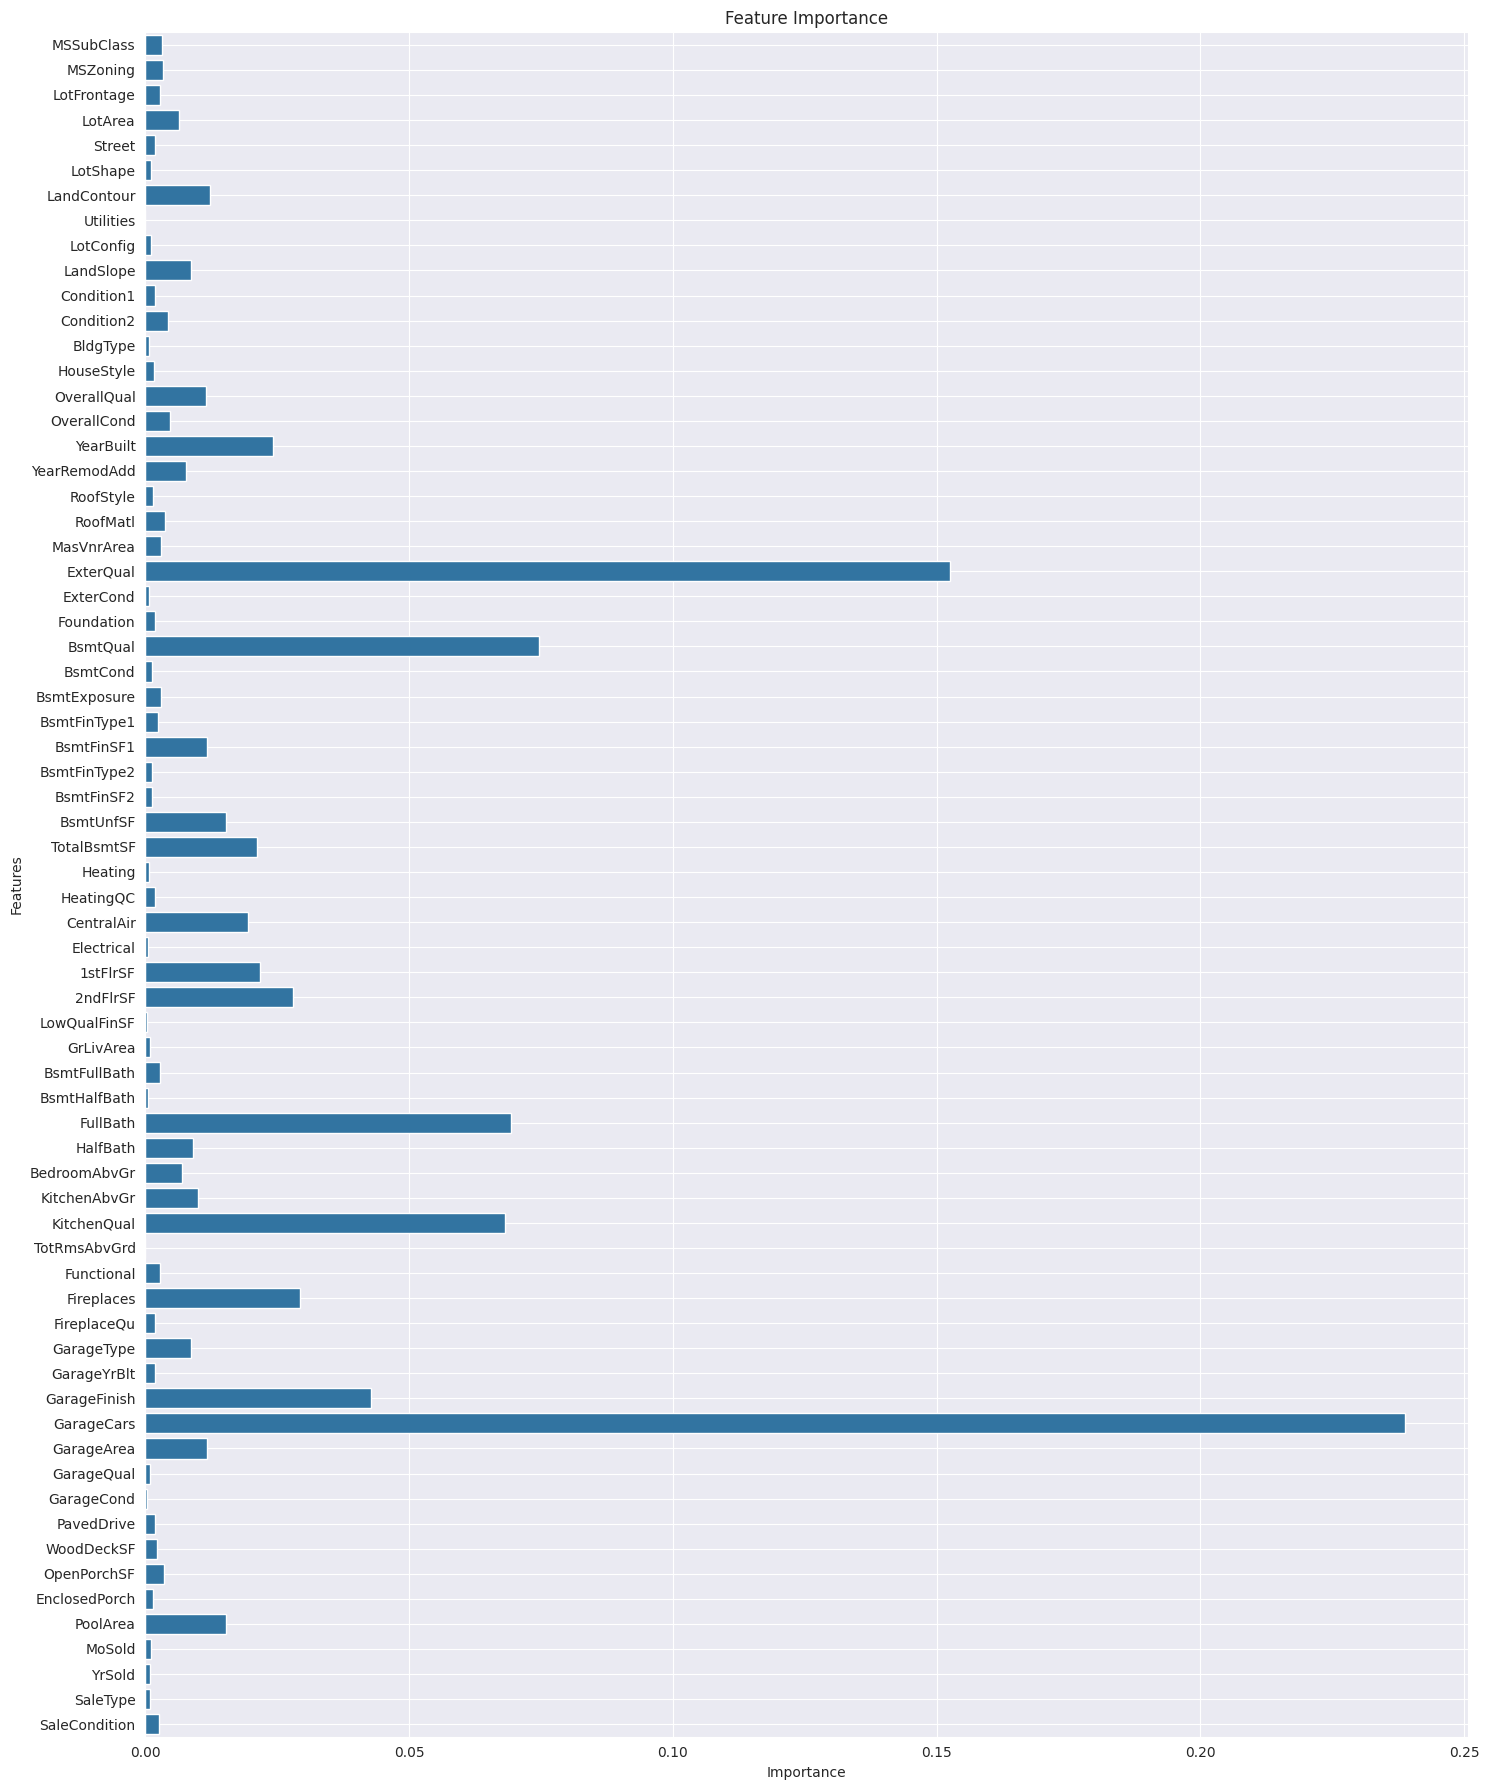

In [67]:
importances = best_xgb_model.feature_importances_
plt.figure(figsize=(15, 18)) 
sns.barplot(x=importances, y=X_train.columns)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.tight_layout()
plt.grid(True)
plt.show()

## ***4.6 Stacking Regressor***

In [68]:
from sklearn.ensemble import StackingRegressor

# moldes
#1. SVR {'C': 500, 'epsilon': 5, 'kernel': 'linear'}
svr_model = SVR(
    C=500,
    kernel="linear",
    epsilon=5
)

#2. RFR
rfr_model = RandomForestRegressor()

#3.XGB
best_xgb_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [69]:
stack_model = StackingRegressor(
    estimators=[
        ("rf", rfr_model),
        ("xgb", best_xgb_model),
        ("svr", svr_model)
    ],
    # final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(X_train_scaled, y_train)

StackingRegressor(cv=5,
                  estimators=[('rf', RandomForestRegressor()),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=0.5,
                                            grow_policy=None,
                                            import...ne,
                                            interaction_constraints=None,
                                            learning_rate=0.03, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1000, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('svr', SVR(C=500, epsilon=5, kernel='linear'))],
                  n_jobs=-1)

In [70]:
y_stack_model_pred = stack_model.predict(X_test_scaled)

print("MSE: ", mean_squared_error(y_test, y_stack_model_pred))
print("R2 score: ", r2_score(y_test, y_stack_model_pred))

MSE:  676088490.893548
R2 score:  0.9118566182674147


## Model Comparison

| Model | MSE | R² Score |
|---|---|---|
| Linear Regression (baseline) | ~1.29B | ~0.83 |
| Lasso Regression (LassoCV) | ~1.37B | ~0.82 |
| Ridge Regression (RidgeCV) | ~1.32B | ~0.82 |
| SVR (default, rbf) | ~7.36B | ~0.03 |
| SVR (tuned, GridSearchCV) | ~1.21B | ~0.84 |
| Random Forest Regressor (default) | ~1.00B | ~0.86 |
| Random Forest Regressor (tuned) | ~1.66B | ~0.78 |
| XGBoost Regressor (default) | ~0.850B | ~0.88 |
| **XGBoost Regressor (tuned)** | **~0.67B** | **~0.91** |
| Stacking Regressor (RF + XGB + SVR) | ~0.677B | ~0.91 |


## Winner: XGBoost Regressor (Tuned)

**Best model:** XGBoost Regressor with RandomizedSearchCV hyperparameter tuning  
**R² Score:** ~0.9117  
**MSE:** ~0.67B  

### Why XGBoost Won:
- XGBoost uses **gradient boosting** — sequentially correcting errors from prior trees — which is especially effective for structured/tabular regression data with many features.
- **Randomized hyperparameter search** over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `gamma` found an optimal configuration that generalised well to the test set.
- Unlike SVR (which struggled with the high-dimensional feature space), XGBoost handles feature interactions and non-linearities naturally.
- The **Stacking Regressor** performed well (R²~0.86) but slightly below the best tuned XGBoost, suggesting that the meta-learner (Ridge, default) did not add sufficient signal over XGBoost alone.

### Key Findings from EDA & Feature Engineering:
- **OverallQual** (overall material and finish quality) was the single strongest predictor of `SalePrice` — higher quality homes command significantly higher prices.
- **GrLivArea** (above-grade living area in sq ft) had a strong positive correlation with price.
- **TotRmsAbvGrd** and **1stFlrSF** also correlated strongly — larger, more-roomed homes cost more.
- **YearBuilt** and **GarageYrBlt** showed that newer construction fetches a premium.
- Squaring the important features (`TotRmsAbvGrd`, `GrLivArea`, `1stFlrSF`, `BsmtUnfSF`) amplified their signal and helped tree-based models exploit magnitude differences.
- Dropping high-cardinality columns (>9 unique categories) before encoding prevented feature-space explosion.
- Columns with >850 missing values (`Alley`, `PoolQC`, `Fence`, `MiscFeature`, `MasVnrType`) were dropped rather than imputed, avoiding noise injection.

### Limitations & Potential Improvements:
- **Log-transforming `SalePrice`** (which is right-skewed) before training could improve RMSE on the Kaggle leaderboard.
- **Feature interactions** (e.g., `OverallQual × GrLivArea`) could further boost tree-based models.
- **Outlier removal** (a few very large `GrLivArea` values with low price) could reduce MSE.
- **Elastic Net** regularisation would combine Lasso and Ridge benefits.

---
# ***6. Test Set Inference & Submission***

In [71]:
test_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
print("Test set shape:", test_df.shape)
test_df.head()

Test set shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## ***6.1 Apply the same preprocessing as training data***

In [72]:
test_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [73]:
# Save Id for submission
test_ids = test_df["Id"]

# --- Drop same high-missing columns as training ---
# Dropping columns which have Missing values > 850
cols_to_drop = ["Alley", "MiscFeature","Fence", "PoolQC", "MasVnrType"]
test_df = test_df.drop(columns=cols_to_drop)

In [74]:
mean_imp = SimpleImputer(strategy="mean")
mode_imp = SimpleImputer(strategy="most_frequent")
median_imp = SimpleImputer(strategy="median")

test_df[["LotFrontage"]] = mean_imp.fit_transform(test_df[["LotFrontage"]])
test_df[["LotFrontage"]] = mean_imp.fit_transform(test_df[["LotFrontage"]])

test_df[["GarageCond"]] = mode_imp.fit_transform(test_df[["GarageCond"]])
test_df[["GarageQual"]] = mode_imp.fit_transform(test_df[["GarageQual"]])
test_df[["GarageFinish"]] = mode_imp.fit_transform(test_df[["GarageFinish"]])
test_df[["GarageType"]] = mode_imp.fit_transform(test_df[["GarageType"]])
test_df[["FireplaceQu"]] = mode_imp.fit_transform(test_df[["FireplaceQu"]])
test_df[["FireplaceQu"]] = mode_imp.fit_transform(test_df[["FireplaceQu"]])
test_df[["Electrical"]] = mode_imp.fit_transform(test_df[["Electrical"]])
test_df[["BsmtFinType2"]] = mode_imp.fit_transform(test_df[["BsmtFinType2"]])
test_df[["BsmtFinType1"]] = mode_imp.fit_transform(test_df[["BsmtFinType1"]])
test_df[["BsmtExposure"]] = mode_imp.fit_transform(test_df[["BsmtExposure"]])
test_df[["BsmtCond"]] = mode_imp.fit_transform(test_df[["BsmtCond"]])
test_df[["BsmtQual"]] = mode_imp.fit_transform(test_df[["BsmtQual"]])

test_df[["GarageYrBlt"]] = median_imp.fit_transform(test_df[["GarageYrBlt"]])
test_df[["MasVnrArea"]] = median_imp.fit_transform(test_df[["MasVnrArea"]])
test_df[["MasVnrArea"]] = median_imp.fit_transform(test_df[["MasVnrArea"]])

cleaned_test_df = test_df

In [75]:
categorical_cols =  cleaned_test_df.select_dtypes(include="object").columns
categorical_cols

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [76]:
cols_to_drop = []
for i in categorical_cols:
    if cleaned_test_df[i].nunique() > 9:
        cols_to_drop.append(i)

print(cols_to_drop)

['Neighborhood', 'Exterior1st', 'Exterior2nd']


In [77]:
new_test_df = cleaned_test_df.drop(columns=cols_to_drop)
new_test_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'Screen

## ***6.2 Encode & Engineer Features (same as training)***

In [78]:
le = LabelEncoder()

new_cate_cols = new_test_df.select_dtypes(include="object").columns

for col in new_cate_cols:
    new_test_df[col] = le.fit_transform(new_test_df[col])

new_test_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,2,80.0,11622,1,3,3,0,4,...,0,0,0,120,0,0,6,2010,8,4
1,1462,20,3,81.0,14267,1,0,3,0,0,...,36,0,0,0,0,12500,6,2010,8,4
2,1463,60,3,74.0,13830,1,0,3,0,4,...,34,0,0,0,0,0,3,2010,8,4
3,1464,60,3,78.0,9978,1,0,3,0,4,...,36,0,0,0,0,0,6,2010,8,4
4,1465,120,3,43.0,5005,1,0,1,0,4,...,82,0,0,144,0,0,1,2010,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,4,21.0,1936,1,3,3,0,4,...,0,0,0,0,0,0,6,2006,8,4
1455,2916,160,4,21.0,1894,1,3,3,0,4,...,24,0,0,0,0,0,4,2006,8,0
1456,2917,20,3,160.0,20000,1,3,3,0,4,...,0,0,0,0,0,0,9,2006,8,0
1457,2918,85,3,62.0,10441,1,3,3,0,4,...,32,0,0,0,0,700,7,2006,8,4


In [79]:
new_test_df["TotRmsAbvGrd"] = new_test_df["TotRmsAbvGrd"]**2
new_test_df["OverallQual"] = new_test_df["TotRmsAbvGrd"]**2
# new_df["GarageYrBlt"] = new_df["TotRmsAbvGrd"]**2 because it will become large value
new_test_df["1stFlrSF"] = new_test_df["TotRmsAbvGrd"]**2
new_test_df["GrLivArea"] = new_test_df["TotRmsAbvGrd"]**2
new_test_df["BsmtUnfSF"] = new_test_df["TotRmsAbvGrd"]**2

In [80]:
new_test_df = new_test_df.drop(columns=["Id", "MiscVal","ScreenPorch", "3SsnPorch"])
new_test_df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,PoolArea,MoSold,YrSold,SaleType,SaleCondition
0,20,2,80.0,11622,1,3,3,0,4,0,...,4,2,140,0,0,0,6,2010,8,4
1,20,3,81.0,14267,1,0,3,0,0,0,...,4,2,393,36,0,0,6,2010,8,4
2,60,3,74.0,13830,1,0,3,0,4,0,...,4,2,212,34,0,0,3,2010,8,4
3,60,3,78.0,9978,1,0,3,0,4,0,...,4,2,360,36,0,0,6,2010,8,4
4,120,3,43.0,5005,1,0,1,0,4,0,...,4,2,0,82,0,0,1,2010,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,4,21.0,1936,1,3,3,0,4,0,...,4,2,0,0,0,0,6,2006,8,4
1455,160,4,21.0,1894,1,3,3,0,4,0,...,4,2,0,24,0,0,4,2006,8,0
1456,20,3,160.0,20000,1,3,3,0,4,0,...,4,2,474,0,0,0,9,2006,8,0
1457,85,3,62.0,10441,1,3,3,0,4,0,...,4,2,80,32,0,0,7,2006,8,4


## ***6.3 Scale the Test Data***

In [81]:
test_scaled = scaler.transform(new_test_df)
test_scaled

array([[-0.8667643 , -1.69586881,  0.4324735 , ...,  1.65006527,
         0.31666197,  0.20177167],
       [-0.8667643 , -0.05479609,  0.47700903, ...,  1.65006527,
         0.31666197,  0.20177167],
       [ 0.07410996, -0.05479609,  0.16526033, ...,  1.65006527,
         0.31666197,  0.20177167],
       ...,
       [-0.8667643 , -0.05479609,  3.99531577, ..., -1.37548612,
         0.31666197, -3.50955605],
       [ 0.66215637, -0.05479609, -0.36916601, ..., -1.37548612,
         0.31666197,  0.20177167],
       [ 0.07410996, -0.05479609,  0.16526033, ..., -1.37548612,
         0.31666197,  0.20177167]])

## ***6.4 Predict using Best Model (XGBoost Tuned)***

In [82]:
test_predictions = best_xgb_model.predict(test_scaled)

print("Prediction Stats:")
print(f"  Min:  ${test_predictions.min():,.0f}")
print(f"  Max:  ${test_predictions.max():,.0f}")
print(f"  Mean: ${test_predictions.mean():,.0f}")

Prediction Stats:
  Min:  $50,219
  Max:  $514,178
  Mean: $179,399


## ***6.5 Create and Save the Kaggle Submission File***

In [4]:
submission = pd.DataFrame({
    "Id":        test_ids.values,
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)
print("Submission saved!  Shape:", submission.shape)
submission.head(10)

NameError: name 'test_ids' is not defined